In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
import sys, os
from collections import defaultdict
sys.path.insert(0, os.path.abspath('..'))
from experiments.summarize_results import _discover_model_types, load_channel_runs, _best_by

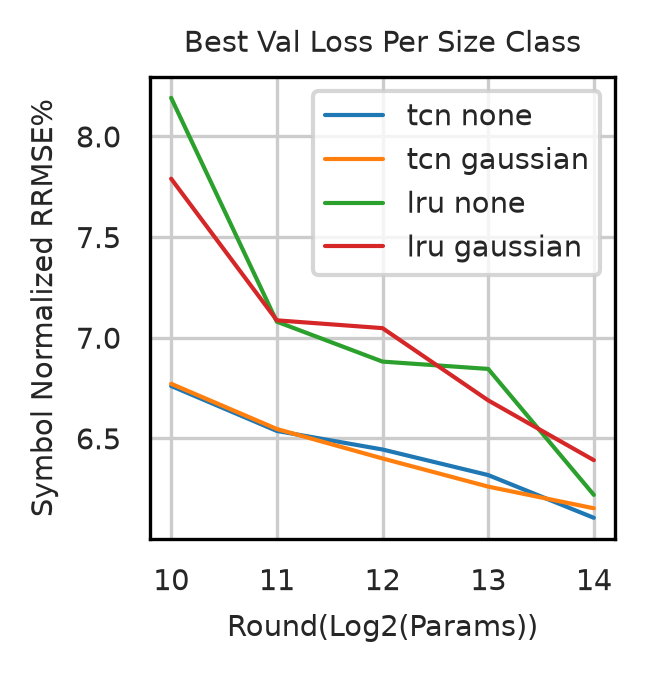

In [18]:
# For 50 mA, get the best channel models per size class and plot val_rrmse vs. parameter count

CHANNEL_EXP_DIR = "data/experiments/train_and_validate/raw_storm_channel_models_20260808_1526"

channel_models = load_channel_runs(CHANNEL_EXP_DIR)

def size_class(params: int):
    return int(round(math.log2(params)))

def best_val_loss_per_size_class(model_list: list[dict]):
    best_per_size = defaultdict(lambda: float('inf'))
    for m in model_list:
        size_m = size_class(m['num_params'])
        model_type_m = m['model'] + " " + m['distribution']
        key = (size_m, model_type_m)
        val_loss_m = m['val_per_burst_rrmse_pct']
        curr_min = best_per_size[key]
        best_per_size[key] = min(val_loss_m, curr_min)
    return best_per_size


best = best_val_loss_per_size_class(channel_models)
# x_vals = np.arange(min([key[0] for key in best]), max([key[0] for key in best]))


# def get_x_y_by_type(model_type: str, best_dict=best):
#     size_classes = np.array([k[0] for k in best_dict if k[1] == model_type])
#     val_losses = np.array([l for k, l in best_dict.items() if k[1] == model_type])
#     ascend_sort = np.argsort(size_classes)
#     return size_classes[ascend_sort], val_losses[ascend_sort]

plt.figure(figsize=(2, 2))
# model_types = {k[1] for k in best}
# for typ in model_types:
#     x, y = get_x_y_by_type(typ)
#     plt.plot(x, y, label=typ)

by_type = defaultdict(list)
for (size, model_type), loss in best.items():
    by_type[model_type].append((size, loss))

for model_type, points in by_type.items():
    points.sort()
    xs, ys = zip(*points)
    plt.plot(xs, ys, label=model_type)

plt.title("Best Val Loss Per Size Class")
plt.xlabel("Round(Log2(Params))")
plt.ylabel("Symbol Normalized RRMSE%")
plt.legend()
plt.show()

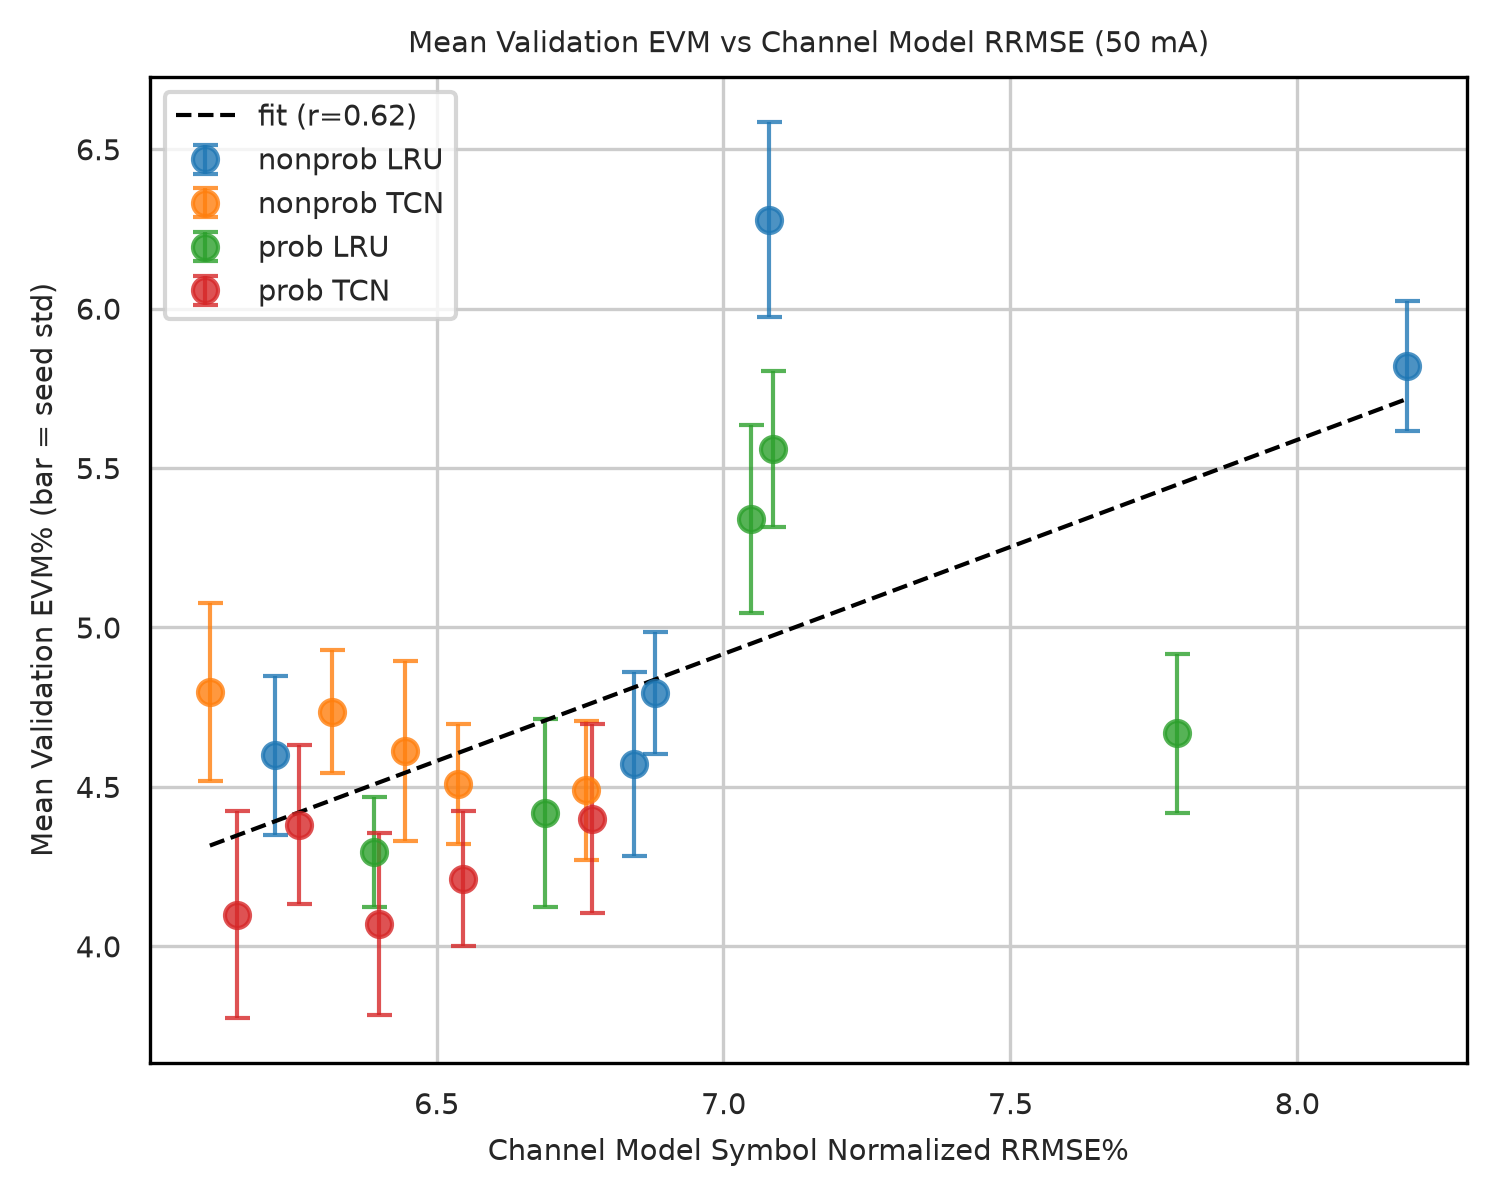

In [19]:
# Seed-averaged: one point per channel model (mean validation EVM over seeds, bar = seed std)
# vs that channel's RRMSE, with the pooled least-squares trend.

from experiments.summarize_results import RUN_CONFIGS, _read_jsonl, _resolve

cfg = next(c for c in RUN_CONFIGS if c["label"] == "50 mA")

channel_models = load_channel_runs(cfg["channel_exp_dir"])
rrmse_by_channel = {m["run_id"]: m["val_per_burst_rrmse_pct"] for m in channel_models}
form_by_channel = {m["run_id"]: ("prob " if m["is_prob"] else "nonprob ") + m["model"].upper()
                   for m in channel_models}

ed_val_rows = _read_jsonl(_resolve(cfg["ed_val_exp_dir"]) / "runs.jsonl")

evm_by_channel = defaultdict(list)
for row in ed_val_rows:
    evm_by_channel[row["channel_run_id"]].append(row["evm_pct"])

points_by_form = defaultdict(lambda: {"rrmse": [], "evm_mean": [], "evm_std": []})
for channel_id, evms in evm_by_channel.items():
    form = points_by_form[form_by_channel[channel_id]]
    form["rrmse"].append(rrmse_by_channel[channel_id])
    form["evm_mean"].append(np.mean(evms))
    form["evm_std"].append(np.std(evms))

all_rrmse = np.array([rrmse_by_channel[c] for c in evm_by_channel])
all_evm_mean = np.array([np.mean(evm_by_channel[c]) for c in evm_by_channel])
slope, intercept = np.polyfit(all_rrmse, all_evm_mean, 1)
r = np.corrcoef(all_rrmse, all_evm_mean)[0, 1]

plt.figure(figsize=(5, 4))

for form, pts in sorted(points_by_form.items()):
    plt.errorbar(pts["rrmse"], pts["evm_mean"], yerr=pts["evm_std"],
                 fmt="o", ms=6, capsize=3, alpha=0.8, label=form)

x_line = np.array([all_rrmse.min(), all_rrmse.max()])
plt.plot(x_line, slope * x_line + intercept, "k--", lw=1, label=f"fit (r={r:.2f})")

plt.title("Mean Validation EVM vs Channel Model RRMSE (50 mA)")
plt.xlabel("Channel Model Symbol Normalized RRMSE%")
plt.ylabel("Mean Validation EVM% (bar = seed std)")
plt.legend()
plt.tight_layout()
plt.show()
